### Censo de Árboles Callejeros 2015 - Datos de árboles
El censo de árboles de 2015 fue el tercer censo decenal de árboles callejeros y la mayor iniciativa de ciencia ciudadana en la historia de NYC Parks. La recopilación de datos se realizó desde mayo de 2015 hasta octubre de 2016 y los resultados del censo muestran que hay 666.134 árboles plantados a lo largo de las calles de Nueva York. Los datos recogidos como parte del censo representan una instantánea temporal de los árboles bajo la jurisdicción de Parques de Nueva York.

### Dataset para descargar

https://data.cityofnewyork.us/Environment/2015-Street-Tree-Census-Tree-Data/uvpi-gqnh/about_data

### Opciones de Hipótesis

* **Predicción de la Salud del Árbol**
  * **Problema:** Predecir el estado de salud a partir de factores del entorno y manejo humano.
  * **Variables clave:** Diámetro (`tree_dbh`), ubicación respecto al cordón (`curb_loc`), presencia de protectores (`guards`), cuidado ciudadano (`steward`), problemas en raíces/tronco (`root_stone`, `trunk_wire`, `problems`), y el distrito (`borough`).

* **Predicción de Daño a la Infraestructura Peatonal**
  * **Problema:** Identificar qué combinaciones de especie, tamaño y condiciones de raíz rompen las aceras (`sidewalk`).
  * **Utilidad práctica:** Permite a los departamentos de obras públicas y parques priorizar inspecciones antes de que se presenten demandas por caídas o roturas de veredas.


### Importamos librerias


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importamos el dataset

In [3]:
trees = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20260914.csv')

### Vemos la cantidad de filas y columnas

In [4]:
trees.shape

(683788, 45)

### Vemos la cantidad de celdas

In [5]:
trees.size

30770460

### Inspecionamos el dataset

In [6]:
trees

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4.073.900,New York,"40,72309177","-73,84421522","1.027.431,148","202.756,7687",29.0,739.000,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4.097.300,New York,"40,79411067","-73,81867946","1.034.455,701","228.644,8374",19.0,973.000,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3.044.900,New York,"40,71758074","-73,9366077","1.001.822,831","200.716,8913",34.0,449.000,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3.044.900,New York,"40,71353749","-73,93445616","1.002.420,358","199.244,2531",34.0,449.000,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,3.016.500,New York,"40,66677776","-73,97597938","990.913,775","182.202,426",39.0,165.000,3025654.0,3.010850e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,3.051.900,New York,"40,71321078","-73,95494401","996.740,686","199.121,6363",34.0,519.000,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Good,Cladrastis kentukea,Kentucky yellowwood,...,4.070.700,New York,"40,71519444","-73,8566502","1.023.989,074","199.873,6475",29.0,707.000,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,5.020.100,New York,"40,62076153","-74,13651724","946.351,4104","165.466,0763",50.0,201.000,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,2.023.502,New York,"40,85082819","-73,90311472","1.011.053,646","249.271,9507",15.0,23.502,2007757.0,2.028120e+09


In [7]:
trees.info()

<class 'pandas.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tree_id           683788 non-null  int64  
 1   block_id          683788 non-null  int64  
 2   created_at        683788 non-null  str    
 3   tree_dbh          683788 non-null  int64  
 4   stump_diam        683788 non-null  int64  
 5   curb_loc          683788 non-null  str    
 6   status            683788 non-null  str    
 7   health            652172 non-null  str    
 8   spc_latin         652169 non-null  str    
 9   spc_common        652169 non-null  str    
 10  steward           164350 non-null  str    
 11  guards            79866 non-null   str    
 12  sidewalk          652172 non-null  str    
 13  user_type         683788 non-null  str    
 14  problems          225844 non-null  str    
 15  root_stone        683788 non-null  str    
 16  root_grate        683788 non-nu

### Inspecionamos los valores faltantes

In [8]:
trees.isnull().sum()

tree_id                  0
block_id                 0
created_at               0
tree_dbh                 0
stump_diam               0
curb_loc                 0
status                   0
health               31616
spc_latin            31619
spc_common           31619
steward             519438
guards              603922
sidewalk             31616
user_type                0
problems            457944
root_stone               0
root_grate               0
root_other               0
trunk_wire               0
trnk_light               0
trnk_other               0
brch_light               0
brch_shoe                0
brch_other               0
address                  0
postcode                 0
zip_city                 0
community board          0
borocode                 0
borough                  0
cncldist                 0
st_assem                 0
st_senate                0
nta                      0
nta_name                 0
boro_ct                  0
state                    0
l

In [9]:
faltantes_totales = trees.isnull().sum().sum()
celdas_totales = trees.size
porcentaje = (faltantes_totales / celdas_totales) * 100

print(f"Faltan {faltantes_totales:,} celdas de un total de {celdas_totales:,} ({porcentaje:.2f}%)")

Faltan 1,739,930 celdas de un total de 30,770,460 (5.65%)


### ¿Cuantos valores faltantes tiene cada columna?

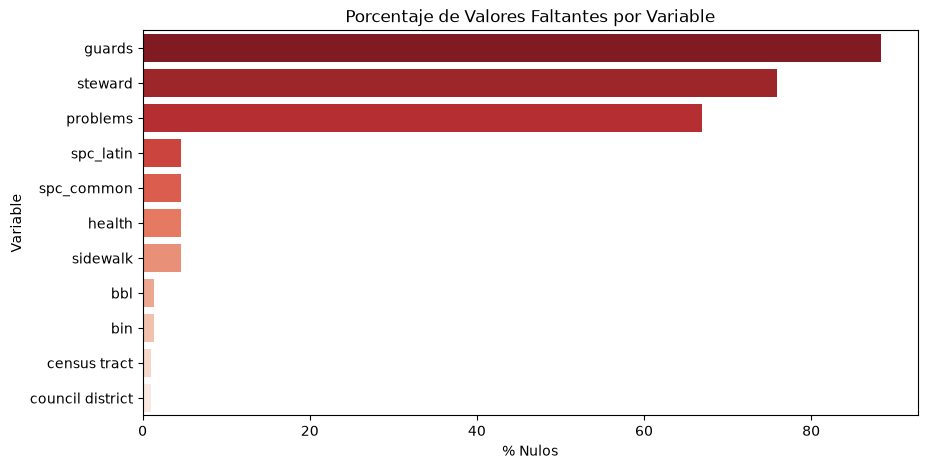

In [10]:
# % de nulos por columna (solo las que tienen faltantes)
missing_series = trees.isnull().mean() * 100
missing_df = missing_series[missing_series > 0].sort_values(ascending=False).reset_index()
missing_df.columns = ['Columna', '% Faltantes']

# Gráfico de barras de valores faltantes
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x='% Faltantes', y='Columna', hue='Columna', palette='Reds_r', legend=False)
plt.title('Porcentaje de Valores Faltantes por Variable')
plt.xlabel('% Nulos')
plt.ylabel('Variable')
plt.show()

### Decisión de Hipotesis

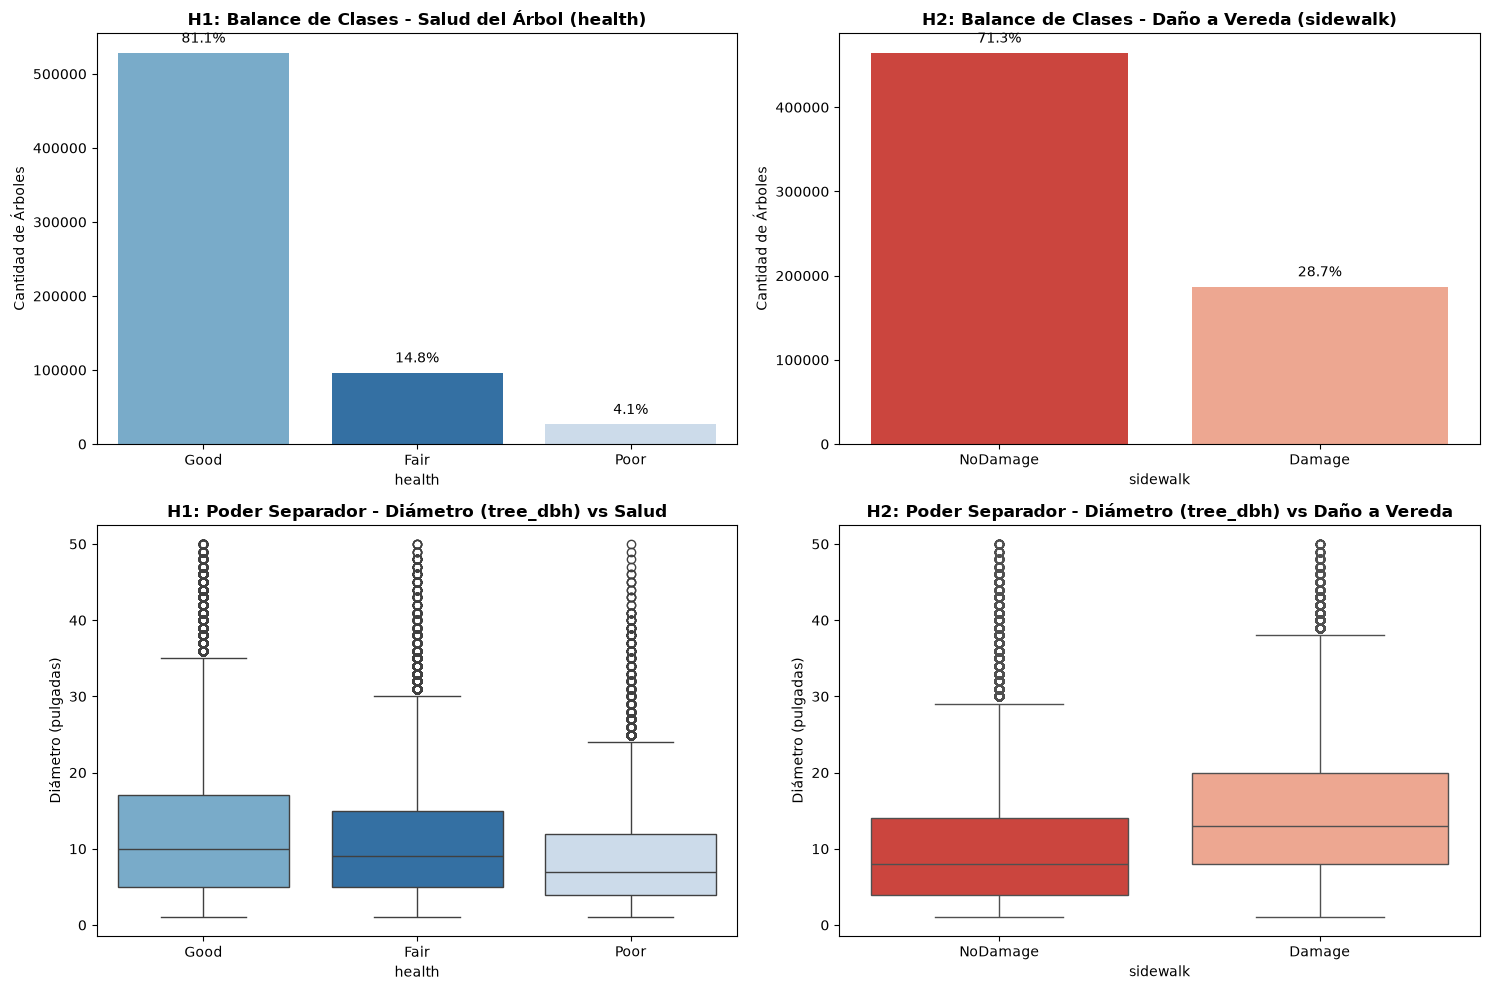

In [ ]:
# 1. Filtrar únicamente árboles vivos (elimina nulos en health y sidewalk)
trees_alive = trees[(trees['status'] == 'Alive') & (trees['tree_dbh'] > 0) & (trees['tree_dbh'] <= 50)].copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- GRÁFICO 1: Balance de Clases en Hipótesis 1 (Salud) ---
sns.countplot(data=trees_alive, x='health', order=['Good', 'Fair', 'Poor'], palette='Blues_r', hue='health', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('H1: Balance de Clases - Salud del Árbol (health)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Cantidad de Árboles')
for p in axes[0, 0].patches:
    percentage = f'{100 * p.get_height() / len(trees_alive):.1f}%'
    axes[0, 0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# --- GRÁFICO 2: Balance de Clases en Hipótesis 2 (Daño a Veredas) ---
sns.countplot(data=trees_alive, x='sidewalk', palette='Reds_r', hue='sidewalk', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('H2: Balance de Clases - Daño a Vereda (sidewalk)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Cantidad de Árboles')
for p in axes[0, 1].patches:
    percentage = f'{100 * p.get_height() / len(trees_alive):.1f}%'
    axes[0, 1].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# --- GRÁFICO 3: Poder Separador H1 (Diámetro vs Salud) ---
sns.boxplot(data=trees_alive, x='health', y='tree_dbh', order=['Good', 'Fair', 'Poor'], palette='Blues_r', hue='health', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('H1: Poder Separador - Diámetro (tree_dbh) vs Salud', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Diámetro (pulgadas)')

# --- GRÁFICO 4: Poder Separador H2 (Diámetro vs Daño en Vereda) ---
sns.boxplot(data=trees_alive, x='sidewalk', y='tree_dbh', palette='Reds_r', hue='sidewalk', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('H2: Poder Separador - Diámetro (tree_dbh) vs Daño a Vereda', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Diámetro (pulgadas)')
plt.tight_layout()
plt.show()

**Conclusión del Análisis de Factibilidad:**

Después de analizar los datos de ambas hipótesis, decidimos avanzar con la Hipótesis 2 (Daño a Veredas) por las siguientes razones:

La Hipótesis 1 (Salud del Árbol) tiene un problema importante: las clases están muy desbalanceadas (el 81.1% de los árboles están en estado Good y solo el 4.1% en Poor). Además, al comparar el diámetro del tronco entre las categorías de salud, las distribuciones se superponen mucho, lo que haría más difícil entrenar un buen modelo.

En cambio, la Hipótesis 2 tiene una distribución mucho más manejable (71.3% NoDamage vs 28.7% Damage) y una relación clara entre el diámetro del árbol y el daño a la vereda: los árboles que rompen la acera tienen un diámetro mediano de 13 pulgadas, un 62% más grande que los que no causan daño (8 pulgadas).

Por todo esto, elegimos la Hipótesis 2 como la más viable para entrenar modelos de clasificación.

## 1. ¿Qué datos tenemos?




In [19]:
# Asignamos df_raw a partir de los datos cargados previamente
df_raw = trees.copy()

print("Dimensiones crudas:", df_raw.shape)
print("\nDistribución de status vs nulos en sidewalk:")
print(pd.crosstab(df_raw['status'], df_raw['sidewalk'].isnull(), rownames=['status'], colnames=['sidewalk_is_null']))

# Filtrado de dominio: conservar solo árboles vivos con target registrado
df = df_raw[(df_raw['status'] == 'Alive') & (df_raw['sidewalk'].notnull())].copy()

# Binarización del target (1: Damage, 0: NoDamage)
df['target'] = (df['sidewalk'] == 'Damage').astype(int)

print(f"\nRegistros restantes tras filtrado: {df.shape[0]} ({df.shape[0]/df_raw.shape[0]*100:.2f}%)")
print("\nDistribución del target:")
print(df['target'].value_counts(normalize=True).rename({0: 'NoDamage (0)', 1: 'Damage (1)'}) * 100)

Dimensiones crudas: (683788, 45)

Distribución de status vs nulos en sidewalk:
sidewalk_is_null   False  True 
status                         
Alive             652172      1
Dead                   0  13961
Stump                  0  17654

Registros restantes tras filtrado: 652172 (95.38%)

Distribución del target:
target
NoDamage (0)    71.296836
Damage (1)      28.703164
Name: proportion, dtype: float64


### Análisis a redactar / Interpretación:
> Se comprobó que de los 31.616 valores nulos en la columna `sidewalk`, 31.615 corresponden a registros clasificados como `'Dead'` o `'Stump'` (y solo un caso aislado en `'Alive'`). Dado que un tocón o árbol muerto no genera las mismas presiones mecánicas radiculares que un árbol vivo, se procedió a excluirlos formalmente.
>
> El dataset operativo (`df`) retiene **652.172 registros (95.38%)** de los datos originales, garantizando integridad biológica y eliminando missingness artificial en la variable objetivo (`target`), la cual presenta una tasa base de daño del **28.70%** (frente a 71.30% sin daño).

## 2. Limpieza de datos

### Qué analizar:
* Nulos masivos en variables de intervención humana (`steward`, `guards`, `problems`).
* Errores de registro y valores biológicamente imposibles en el diámetro del tronco (`tree_dbh`).

In [22]:
# 1. Imputación semántica (ausencia de evento, no dato perdido)
df['steward'] = df['steward'].fillna('None')
df['guards'] = df['guards'].fillna('None')
df['problems'] = df['problems'].fillna('None')

# 2. Resumen estadístico del diámetro antes de filtrar
print("Estadísticas de tree_dbh antes de limpieza:")
print(df['tree_dbh'].describe(percentiles=[0.01, 0.5, 0.99, 0.999]))

# 3. Filtrado de outliers de diámetro (exclusión de 0 y valores > 60 pulgadas)
df_clean = df[(df['tree_dbh'] > 0) & (df['tree_dbh'] <= 60)].copy()

print(f"\nRegistros descartados por outliers en diámetro: {len(df) - len(df_clean)}")
print(f"Registros limpios restantes en df_clean: {len(df_clean)} ({len(df_clean)/len(df)*100:.2f}%)")

Estadísticas de tree_dbh antes de limpieza:
count    652172.000000
mean         11.709492
std           8.634244
min           0.000000
1%            2.000000
50%          10.000000
99%          37.000000
99.9%        47.000000
max         425.000000
Name: tree_dbh, dtype: float64

Registros descartados por outliers en diámetro: 372
Registros limpios restantes en df_clean: 651800 (99.94%)


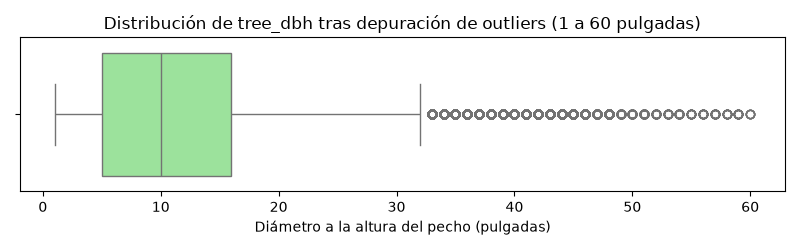

In [23]:
# Boxplot horizontal de tree_dbh tras depuración de outliers
fig, ax = plt.subplots(figsize=(8, 2.5))
sns.boxplot(x=df_clean['tree_dbh'], color="lightgreen", ax=ax)
ax.set_title("Distribución de tree_dbh tras depuración de outliers (1 a 60 pulgadas)")
ax.set_xlabel("Diámetro a la altura del pecho (pulgadas)")
plt.tight_layout()
plt.show()

### Análisis a redactar / Interpretación:
> Las variables `steward`, `guards` y `problems` fueron imputadas con la etiqueta `'None'` al confirmar que la ausencia de registro representa falta de intervención humana o ausencia de problema registrado, y no una omisión accidental de captura.
>
> En cuanto a `tree_dbh`, se eliminaron registros con diámetro igual a 0 y valores superiores a 60 pulgadas (~1.5 metros de diámetro de fuste). El análisis de percentiles demostró que el percentil 99.9 se ubica en 47 pulgadas, mientras que los valores extremos llegaban hasta 425 pulgadas, correspondiendo a errores tipográficos severos incompatibles con árboles plantados en aceras urbanas.
>
> Con este criterio se descartaron solo 372 registros anómalos, reteniendo **651.800 árboles válidos (99.94% de df)** con una distribución físicamente coherente y lista para el análisis exploratorio y modelado.

## 3. ¿Qué factores influyen en el daño a las veredas?


In [24]:
# 1. Proporción del Target
balance = df_clean['target'].value_counts(normalize=True) * 100
print(f"Proporción NoDamage (0): {balance[0]:.2f}% | Damage (1): {balance[1]:.2f}%")

# 2. Agrupación por bines de diámetro para observar la tendencia
df_clean['dbh_binned'] = pd.cut(df_clean['tree_dbh'], bins=[0, 6, 12, 18, 24, 36, 60])
damage_by_size = df_clean.groupby('dbh_binned', observed=True)['target'].mean().reset_index()
print("\nTasa de daño por intervalo de diámetro:")
print(damage_by_size)

Proporción NoDamage (0): 71.29% | Damage (1): 28.71%

Tasa de daño por intervalo de diámetro:
  dbh_binned    target
0     (0, 6]  0.154156
1    (6, 12]  0.280658
2   (12, 18]  0.391433
3   (18, 24]  0.420489
4   (24, 36]  0.456159
5   (36, 60]  0.492720


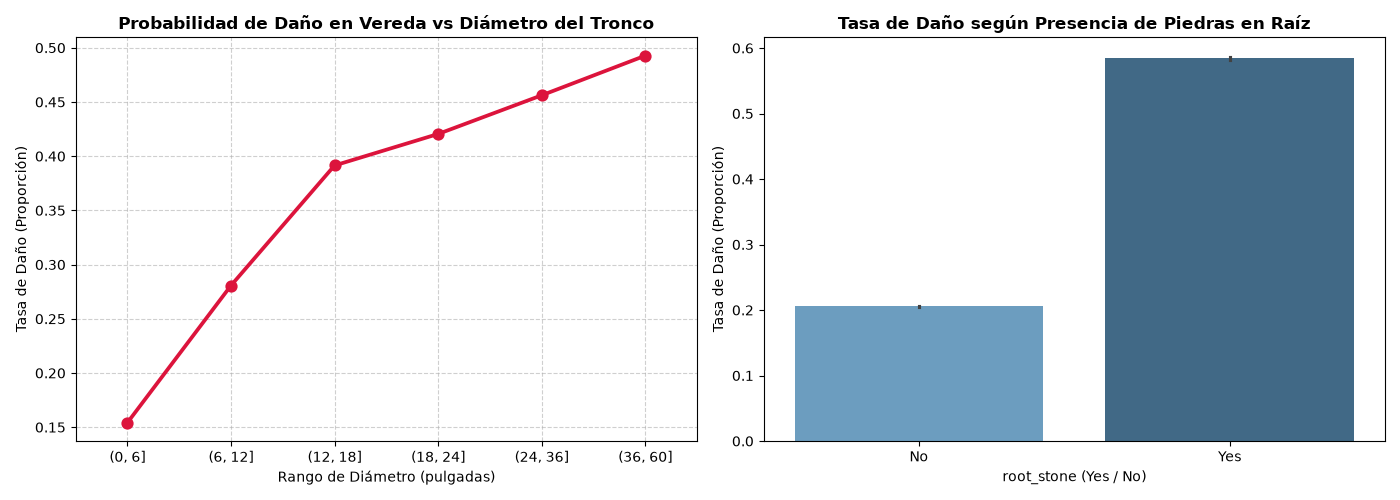

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curva de daño vs tamaño
sns.pointplot(data=damage_by_size, x='dbh_binned', y='target', ax=axes[0], color='crimson')
axes[0].set_title("Probabilidad de Daño en Vereda vs Diámetro del Tronco", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Tasa de Daño (Proporción)")
axes[0].set_xlabel("Rango de Diámetro (pulgadas)")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico 2: Impacto de root_stone
sns.barplot(data=df_clean, x='root_stone', y='target', ax=axes[1], palette="Blues_d", hue='root_stone', legend=False)
axes[1].set_title("Tasa de Daño según Presencia de Piedras en Raíz", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Tasa de Daño (Proporción)")
axes[1].set_xlabel("root_stone (Yes / No)")

plt.tight_layout()
plt.show()

El target tiene un 28.71% de casos con daño frente a un 71.29% sin daño. Esto significa que hay más árboles que no dañan la vereda que los que sí, algo que hay que tener en cuenta a la hora de evaluar el modelo, porque si simplemente dijera "no hay daño" para todos los casos, acertaría el 71% de las veces sin haber aprendido nada.

Al agrupar los árboles por diámetro, se ve una tendencia clara: los árboles chicos (hasta 6 pulgadas) dañan la vereda solo un 15.42% de las veces, pero a medida que crecen la tasa sube rápido, llegando a 28.07% en el rango de 6 a 12 pulgadas y superando el 45-50% en los de más de 24 pulgadas. Cuanto más grande el árbol, más probable es que rompa la acera.

También se observó que cuando hay piedras levantadas por las raíces (root_stone = 'Yes'), la tasa de daño pasa de 25.7% a casi 50%, prácticamente el doble. Esto lo convierte en uno de los indicadores más fuertes de que la vereda va a tener daño.